# Business Problem Given:
#### Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Goal is to uncover patterns that could inform smarter trading strategies.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from datetime import datetime

## Part A — Data preparation
Load both datasets and document:

number of rows/columns

missing values / duplicates

Convert timestamps and align the datasets by date (daily level).

In [3]:
sentiment_df=pd.read_csv('fear_greed_index.csv')
trader_df=pd.read_csv('historical_data.csv')

In [4]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
sentiment_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 127.5 KB


In [6]:
trader_df.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
trader_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [8]:
print(f'Number of rows and columns in fear_greed_index(sentiment) dataset: {sentiment_df.shape}')
print(f'Number of rows and columns in historical_data(Hyperlink data) dataset: {trader_df.shape}')

Number of rows and columns in fear_greed_index(sentiment) dataset: (2644, 4)
Number of rows and columns in historical_data(Hyperlink data) dataset: (211224, 16)


In [9]:
#checking duplicates in fear_greed_index dataset
sentiment_df[sentiment_df.duplicated()].count()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
#Checking Null values
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
#checking duplicate rows in historical_data dataset
trader_df[trader_df.duplicated()].count()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [12]:
# checking Null values
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
#unique categories of direction of trade
trader_df['Direction'].unique()

<ArrowStringArray>
[                      'Buy',                      'Sell',
                 'Open Long',                'Close Long',
      'Spot Dust Conversion',                'Open Short',
               'Close Short',              'Long > Short',
              'Short > Long',         'Auto-Deleveraging',
 'Liquidated Isolated Short',                'Settlement']
Length: 12, dtype: str

## Data Cleaning and Preprocessing

In [14]:
#filtering trades which are closed based on trade direction into a new dataframe for trade analysis. Instead of groupby on each trader which cannot give accurate closed_PnL, I have taken only closed deals rows.
close_events = [
    'Close Long',
    'Close Short',
    'Liquidated Isolated Short',
    'Auto-Deleveraging',
    'Settlement'
]
closed_df = trader_df[trader_df['Direction'].isin(close_events)].copy().reset_index(drop=True)

In [15]:
#calculating total closed_PnL column and a boolean is_profit column if closed trade is a profit or a loss.
closed_df['net_pnl'] = closed_df['Closed PnL'] - closed_df['Fee']
closed_df['is_profit'] = closed_df['net_pnl'] > 0
closed_df['is_loss']=closed_df['net_pnl']<0

In [16]:
closed_df['net_pnl'].describe()

count     84701.000000
mean         85.696874
std        1313.230291
min     -118071.556516
25%           0.353721
50%           5.593752
75%          35.791452
max      135299.803088
Name: net_pnl, dtype: float64

In [17]:
#filtering flip trades based on direction column in trade_df
df_flips = trader_df[trader_df['Direction'].isin(['Long > Short', 'Short > Long'])]

In [18]:
df_flips.info()

<class 'pandas.DataFrame'>
Index: 127 entries, 3029 to 205785
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           127 non-null    str    
 1   Coin              127 non-null    str    
 2   Execution Price   127 non-null    float64
 3   Size Tokens       127 non-null    float64
 4   Size USD          127 non-null    float64
 5   Side              127 non-null    str    
 6   Timestamp IST     127 non-null    str    
 7   Start Position    127 non-null    float64
 8   Direction         127 non-null    str    
 9   Closed PnL        127 non-null    float64
 10  Transaction Hash  127 non-null    str    
 11  Order ID          127 non-null    int64  
 12  Crossed           127 non-null    bool   
 13  Fee               127 non-null    float64
 14  Trade ID          127 non-null    float64
 15  Timestamp         127 non-null    float64
dtypes: bool(1), float64(8), int64(1), str(6)
memory usage:

In [19]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
closed_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,net_pnl,is_profit,is_loss
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.49,14.78,3584.00,SELL,03-12-2024 20:56,1000.00,Close Long,139.418262,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.254400,2.380000e+14,1.730000e+12,138.163862,True,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.47,8.65,2097.37,SELL,03-12-2024 20:56,985.22,Close Long,81.421585,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.734077,4.160000e+14,1.730000e+12,80.687508,True,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.46,13.67,3314.43,SELL,03-12-2024 20:56,976.57,Close Long,128.537643,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.160049,1.120000e+15,1.730000e+12,127.377594,True,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.45,0.06,14.55,SELL,03-12-2024 20:56,962.90,Close Long,0.563574,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.005091,5.980000e+13,1.730000e+12,0.558483,True,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.36,3.68,891.88,SELL,03-12-2024 20:56,962.84,Close Long,34.234672,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.312159,6.480000e+14,1.730000e+12,33.922513,True,False


In [21]:
closed_df['date'] = pd.to_datetime(closed_df['Timestamp IST'], dayfirst=True).dt.normalize()


In [22]:
df_flips['date'] = pd.to_datetime(df_flips['Timestamp IST'], dayfirst=True).dt.normalize()

In [23]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], format='mixed').dt.normalize()

In [24]:
#now merging sentiment dataframe with closed_df and df_flips
#sentiment_df['Date'] = pd.to_datetime(sentiment_df['date'])
#sentiment_df['date'] = sentiment_df['date'].dt.date

closed_df = closed_df.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)
flips_df = df_flips.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

In [25]:
closed_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,net_pnl,is_profit,is_loss,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.49,14.78,3584.00,SELL,03-12-2024 20:56,1000.00,Close Long,139.418262,...,52305625381,True,1.254400,2.380000e+14,1.730000e+12,138.163862,True,False,2024-12-03,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.47,8.65,2097.37,SELL,03-12-2024 20:56,985.22,Close Long,81.421585,...,52305625381,True,0.734077,4.160000e+14,1.730000e+12,80.687508,True,False,2024-12-03,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.46,13.67,3314.43,SELL,03-12-2024 20:56,976.57,Close Long,128.537643,...,52305625381,True,1.160049,1.120000e+15,1.730000e+12,127.377594,True,False,2024-12-03,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.45,0.06,14.55,SELL,03-12-2024 20:56,962.90,Close Long,0.563574,...,52305625381,True,0.005091,5.980000e+13,1.730000e+12,0.558483,True,False,2024-12-03,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.36,3.68,891.88,SELL,03-12-2024 20:56,962.84,Close Long,34.234672,...,52305625381,True,0.312159,6.480000e+14,1.730000e+12,33.922513,True,False,2024-12-03,Extreme Greed


In [26]:
flips_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,14.999,33.33000,499.92,SELL,19-03-2025 21:00,0.01000,Long > Short,0.021049,0xc239806b8bd2a00fc7f4041fdd77fd0201d000de6f21...,80760806418,True,0.167971,6.260000e+12,1.740000e+12,2025-03-19,Fear
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,81403.000,2.78491,226700.03,BUY,09-04-2025 23:03,-2.77036,Short > Long,-17742.216550,0xe4cb606ce315e0c724790421390c5e02059f005d0edc...,85369144282,False,21.763201,1.060000e+15,1.740000e+12,2025-04-09,Extreme Fear
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,81167.000,0.21619,17547.49,SELL,10-04-2025 19:08,0.01437,Long > Short,-3.391320,0x08097d0555c3b1eea999042146d61a02031e0000f891...,85584416119,True,5.895957,4.430000e+14,1.740000e+12,2025-04-10,Fear
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87374.000,1.71675,149999.31,BUY,21-04-2025 17:51,-0.88952,Short > Long,-576.320008,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e...,87783068153,True,34.499842,5.870000e+14,1.750000e+12,2025-04-21,Fear
4,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,2715.000,85.86360,233119.67,SELL,03-02-2025 21:14,21.95270,Long > Short,1169.859383,0x047486372fb2b3f95d84041d10ff73020558001d52ce...,69064166553,False,11.655983,6.260000e+13,1.740000e+12,2025-02-03,Fear


#### Creating key metrics from closed trades and flip trades datasets created above.

In [27]:
closed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84701 entries, 0 to 84700
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           84701 non-null  str           
 1   Coin              84701 non-null  str           
 2   Execution Price   84701 non-null  float64       
 3   Size Tokens       84701 non-null  float64       
 4   Size USD          84701 non-null  float64       
 5   Side              84701 non-null  str           
 6   Timestamp IST     84701 non-null  str           
 7   Start Position    84701 non-null  float64       
 8   Direction         84701 non-null  str           
 9   Closed PnL        84701 non-null  float64       
 10  Transaction Hash  84701 non-null  str           
 11  Order ID          84701 non-null  int64         
 12  Crossed           84701 non-null  bool          
 13  Fee               84701 non-null  float64       
 14  Trade ID          84701 non-null 

In [28]:
#Daily PnL per trader - How much profit does a trader make per day on average?
daily_pnl = closed_df.groupby(['Account', 'date'])['net_pnl'].sum().reset_index()
daily_pnl_per_trader = daily_pnl.groupby('Account')['net_pnl'].mean()

#WIN RATE - How often does a trader make profitable trades??
closed_df['is_win'] = closed_df['net_pnl'] > 0
win_rate = closed_df.groupby('Account')['is_win'].mean()

#AVERAGE TRADE SIZE - How big are trades on average??
avg_trade_size = closed_df.groupby('Account')['Size USD'].mean()


In [29]:

#### Analyzing the key metrics created above to identify trends and patterns.
#Do traders earn more during Fear or Greed?


In [30]:

pnl_by_sentiment = closed_df.groupby('classification')['net_pnl'].mean()

#Long vs Short Ratio - Does the trader prefer long or short positions?
closed_df['is_long'] = closed_df['Direction'].str.contains('Long')
long_short_ratio = closed_df.groupby('Account')['is_long'].mean()

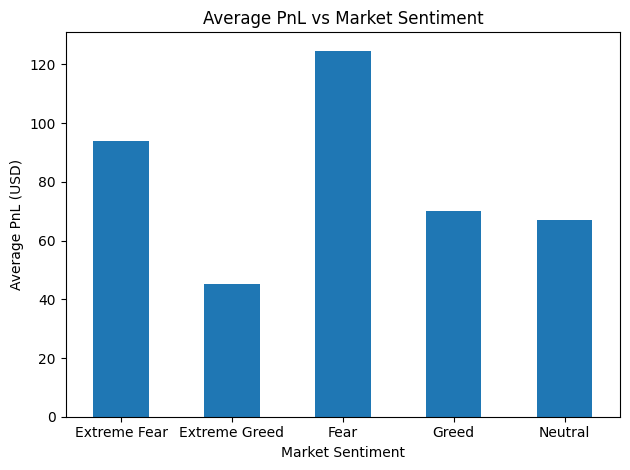

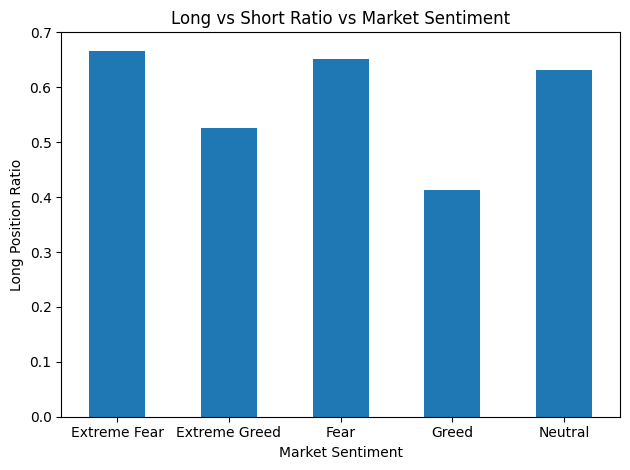

In [31]:
closed_df.groupby('classification')['net_pnl'].mean().plot(kind='bar')
plt.title('Average PnL vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average PnL (USD)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("01_avg_pnl_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
closed_df['is_long'] = closed_df['Direction'].str.contains('Long')

closed_df.groupby('classification')['is_long'].mean().plot(kind='bar')

plt.title('Long vs Short Ratio vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long Position Ratio')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("02_long_short_ratio_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

PLot 1: average PnL vs market sentiment 
Key Observations:
                    approx
Fear → Highest PnL (-125),
Extreme Fear → High PnL (-95),
Greed → Moderate PnL (-70),
Neutral → Moderate PnL (-68),
Extreme Greed → Lowest PnL(-45),

Plot 2: Long vs Short Ratio
Key Observations:

Fear & Extreme Fear → Mostly LONG (0.65–0.67)
Greed → Mostly SHORT (0.41)
Extreme Greed → Mixed (0.53)

hence, 
Longing During Fear = HIGH PROFITS
Traders go long in Fear
And PnL is highest in Fear ,this strategy is working

Shorting During Greed = LOWER PROFITS
Traders go short in Greed , but PnL is only moderate

In [32]:
#As margin values are not known to find leverage directly, I have taken Size_USD field as a proxy for leverage distribution
leverage_dist = closed_df['Size USD'].describe()
leverage_dist


count    8.470100e+04
mean     6.637671e+03
std      4.384151e+04
min      1.000000e-02
25%      2.099800e+02
50%      6.445200e+02
75%      2.222650e+03
max      3.921431e+06
Name: Size USD, dtype: float64

##### Crossed column attribute in historical_dataset is used to analyze aggression Parameter of traders 

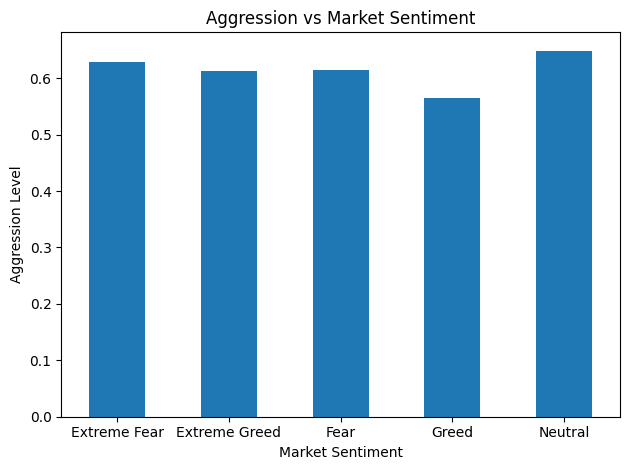

In [33]:

#Aggressive Risk - Are traders doing large AND aggressive trades?
'''what this does is calculates aggressive risk column by using size_usd and crossed column. crossed column is boolean as 0/1. so it identifies large size aggressive and risky trades.'''
closed_df['aggressive_risk'] = closed_df['Size USD'] * (1 + closed_df['Crossed'].astype(int))

#Are traders more aggressive in Fear or Greed?
closed_df['Crossed'] = closed_df['Crossed'].astype(int)
aggression_by_sentiment = closed_df.groupby('classification')['Crossed'].mean()
closed_df['Crossed'] = closed_df['Crossed'].astype(int)

closed_df.groupby('classification')['Crossed'].mean().plot(kind='bar')

plt.title('Aggression vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Aggression Level')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("03_aggression_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

Aggression vs Market Sentiment shows traders are slightly more aggressive on fear and neutral days than on greed days.

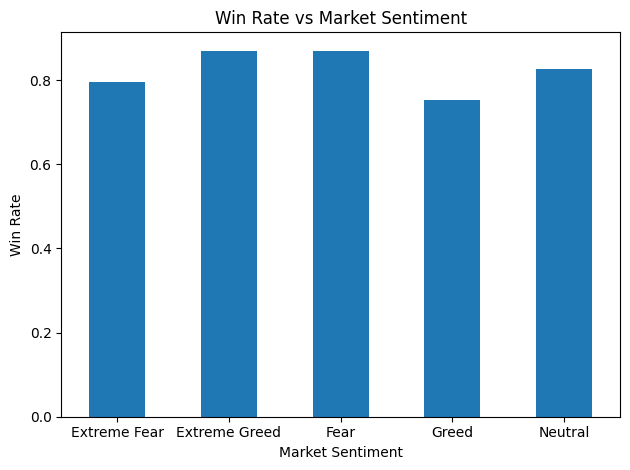

In [34]:
#Are traders more accurate in Fear or Greed?
winrate_by_sentiment = closed_df.groupby('classification')['is_win'].mean()
closed_df.groupby('classification')['is_win'].mean().plot(kind='bar')

plt.title('Win Rate vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("04_winrate_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


Fear Trades have higher win rate than greed trades.

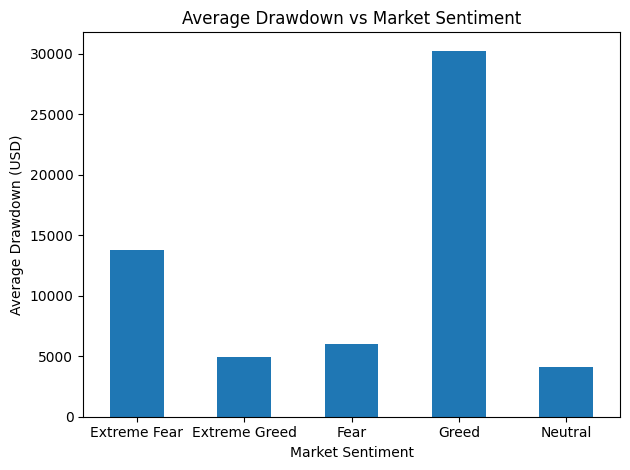

In [35]:
#Drawdown Proxy per trader
closed_df['cum_pnl'] = closed_df.groupby('Account')['net_pnl'].cumsum()
closed_df['running_max'] = closed_df.groupby('Account')['cum_pnl'].cummax()
closed_df['drawdown'] = closed_df['running_max'] - closed_df['cum_pnl']
max_drawdown = closed_df.groupby('Account')['drawdown'].max()
closed_df.groupby('classification')['drawdown'].mean().plot(kind='bar')


plt.title('Average Drawdown vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Drawdown (USD)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("05_drawdown_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


Average drawdown is higher on greed days than fear days. 

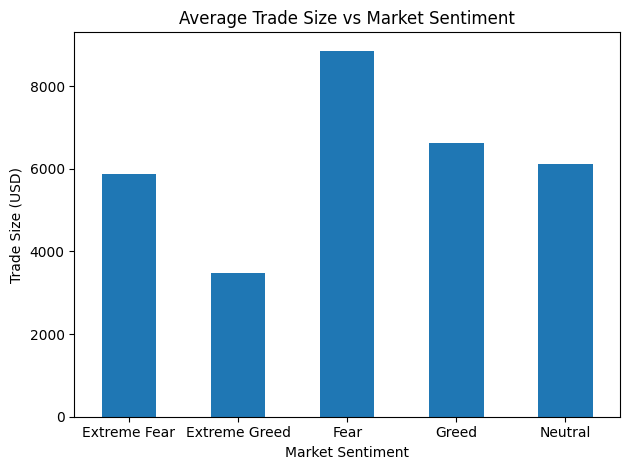

In [36]:

#Do traders trade more in certain market conditions?
trades_by_sentiment = closed_df.groupby('classification').size()
trades_by_sentiment
closed_df.groupby('classification')['Size USD'].mean().plot(kind='bar')

plt.title('Average Trade Size vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size (USD)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("06_trade_size_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


Average Trade Size vs Market Sentiment shows trade size is lowest on extreme greed days and highest on fear days.

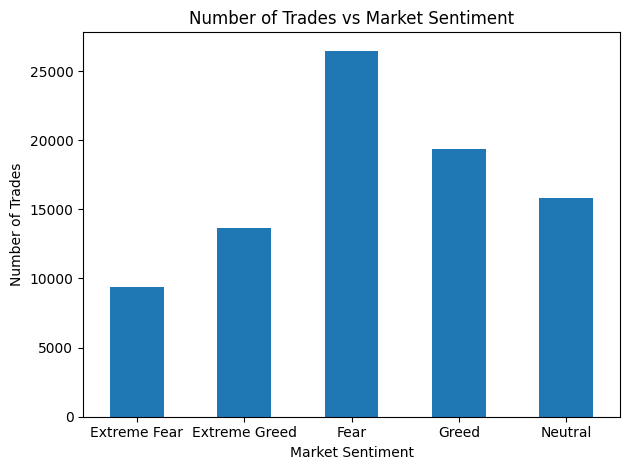

In [37]:

closed_df.groupby('classification').size().plot(kind='bar')

plt.title('Number of Trades vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("07_num_trades_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


Number of Trades vs Market Sentiment shows more trades are performed on fear days than greed days and least number of trades are performed on extreme fear days.

In [38]:
flips_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,14.999,33.33000,499.92,SELL,19-03-2025 21:00,0.01000,Long > Short,0.021049,0xc239806b8bd2a00fc7f4041fdd77fd0201d000de6f21...,80760806418,True,0.167971,6.260000e+12,1.740000e+12,2025-03-19,Fear
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,81403.000,2.78491,226700.03,BUY,09-04-2025 23:03,-2.77036,Short > Long,-17742.216550,0xe4cb606ce315e0c724790421390c5e02059f005d0edc...,85369144282,False,21.763201,1.060000e+15,1.740000e+12,2025-04-09,Extreme Fear
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,81167.000,0.21619,17547.49,SELL,10-04-2025 19:08,0.01437,Long > Short,-3.391320,0x08097d0555c3b1eea999042146d61a02031e0000f891...,85584416119,True,5.895957,4.430000e+14,1.740000e+12,2025-04-10,Fear
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87374.000,1.71675,149999.31,BUY,21-04-2025 17:51,-0.88952,Short > Long,-576.320008,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e...,87783068153,True,34.499842,5.870000e+14,1.750000e+12,2025-04-21,Fear
4,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,2715.000,85.86360,233119.67,SELL,03-02-2025 21:14,21.95270,Long > Short,1169.859383,0x047486372fb2b3f95d84041d10ff73020558001d52ce...,69064166553,False,11.655983,6.260000e+13,1.740000e+12,2025-02-03,Fear


In [39]:
#Are flip trades profitable?
flips_df['net_pnl'] = flips_df['Closed PnL'] - flips_df['Fee']
flips_df['is_profit'] = flips_df['net_pnl'] > 0
flips_df['is_loss']=flips_df['net_pnl']<0
flip_pnl = flips_df.groupby('classification')['net_pnl'].mean()
pd.DataFrame(flip_pnl)

,net_pnl
classification,
Extreme Fear,-1057.603549
Extreme Greed,53.055507
Fear,626.295092
Greed,67.531689
Neutral,18.722253


### Some Deeper Insights

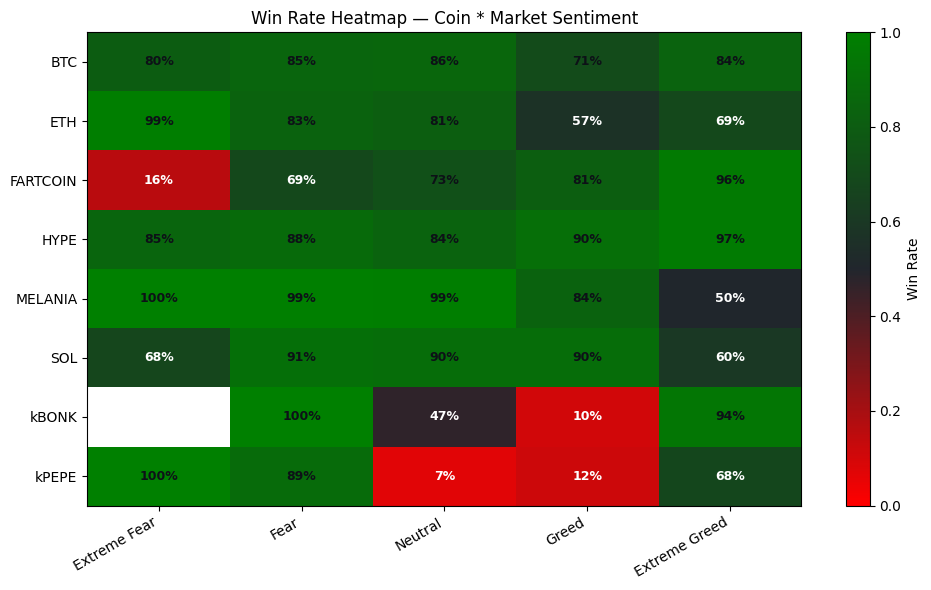

In [40]:
SENT_COLORS = {
    "Extreme Fear": "#818cf8", "Fear": 'FEAR',
    "Neutral": 'GOLD', "Greed": 'GREED', "Extreme Greed": 'RED'
}
SENT_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
PALETTE = ['GREEN', 'GREED', 'FEAR', 'GOLD', 'PURPLE', 'RED', "#34d399",
           "#fb7185", "#a3e635", "#22d3ee", "#f472b6", "#818cf8"]
TOP_COINS = closed_df["Coin"].value_counts().head(8).index.tolist()
 
import matplotlib
coin_sent = (
    closed_df[closed_df["Coin"].isin(TOP_COINS)]
    .groupby(["Coin", "classification"])["is_win"]
    .mean().unstack()[SENT_ORDER]
)
 
fig, ax = plt.subplots(figsize=(10, 6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "rg", ['RED', "#21262d", 'GREEN'])
im = ax.imshow(coin_sent.values, cmap=cmap, aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Win Rate")
 
ax.set_xticks(range(len(coin_sent.columns)))
ax.set_xticklabels(coin_sent.columns, rotation=30, ha="right")
ax.set_yticks(range(len(coin_sent.index)))
ax.set_yticklabels(coin_sent.index)
 
for i in range(len(coin_sent.index)):
    for j in range(len(coin_sent.columns)):
        val = coin_sent.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if val < 0.7 else "#0d1117")
 
ax.set_title("Win Rate Heatmap — Coin * Market Sentiment")
plt.tight_layout()
plt.savefig("08_winrate_heatmap_coin_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
 

### Coin categories vs Market Sentiment Insights
####  kPEPE drops to 12% win rate on Greed days and gives 100% win rate on Extreme Fear days.
#### kBONK has not been traded on extreme fear days by traders and has a win rate of 100% on fear days.
#### SOL gives 90% win rate on both greed and neutral days.
#### MELANIA gives 100% win rate on extreme fear and fear days.
#### ETH gives 99% win rate on extreme fear days.
#### FARTCOIN gives poor win rate on extreme fear days, kPEPE gives poor win rate on neutral and greed days and kBONK gives poor win rate on greed days.

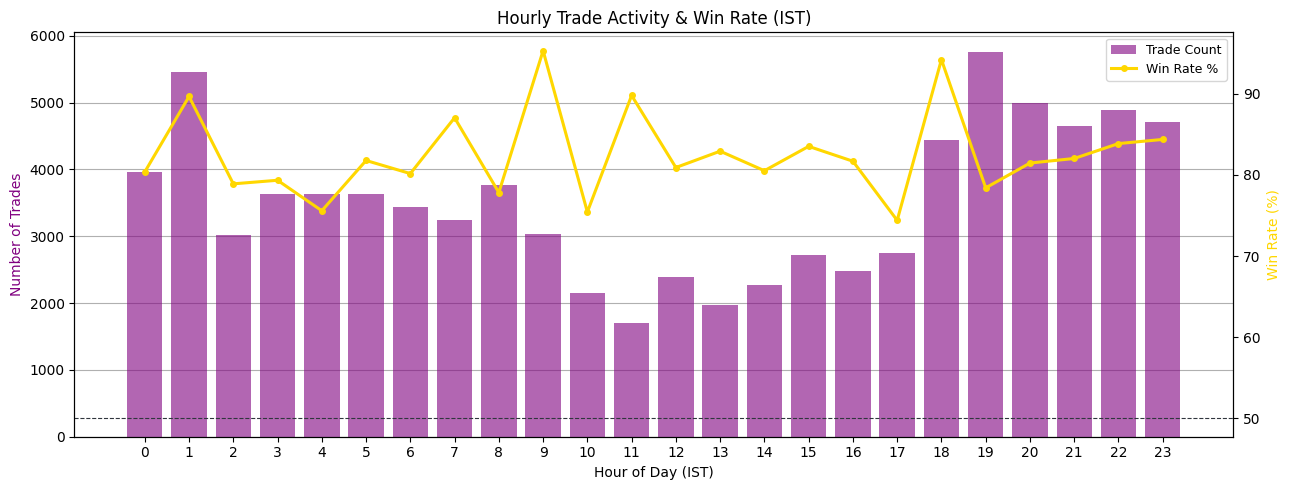

In [41]:
closed_df["hour"] = pd.to_datetime(
    closed_df["Timestamp IST"], dayfirst=True).dt.hour
 
hourly = closed_df.groupby("hour").agg(
    trade_count=("is_win", "count"),
    win_rate=("is_win", "mean")
).reset_index()
 
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
 
ax1.bar(hourly["hour"], hourly["trade_count"],
        color='PURPLE', alpha=0.6, label="Trade Count", zorder=2)
ax2.plot(hourly["hour"], hourly["win_rate"] * 100,
         color='GOLD', linewidth=2.2, marker="o", markersize=4,
         label="Win Rate %", zorder=3)
ax2.axhline(50, color="#30363d", linewidth=0.8, linestyle="--")
 
ax1.set_xlabel("Hour of Day (IST)")
ax1.set_ylabel("Number of Trades", color='PURPLE')
ax2.set_ylabel("Win Rate (%)", color='GOLD')
ax1.set_xticks(range(24))
ax1.set_title("Hourly Trade Activity & Win Rate (IST)")
ax1.grid(True, axis="y", zorder=0)
 
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("09_hourly_activity_winrate.png", dpi=150, bbox_inches="tight")
plt.show()

### Hourly Trades vs Win rate Insights
### Hourly Trades vs Win rate shows that trades executed between 12 PM to 4 PM and between 7 PM to 11 PM have consistently higher win rates (above 80%). This suggests that traders may get higher win rate during certain hours of the day. 
### Also, Trades executed around 9 AM and 6 PM have highest win rate(peak).

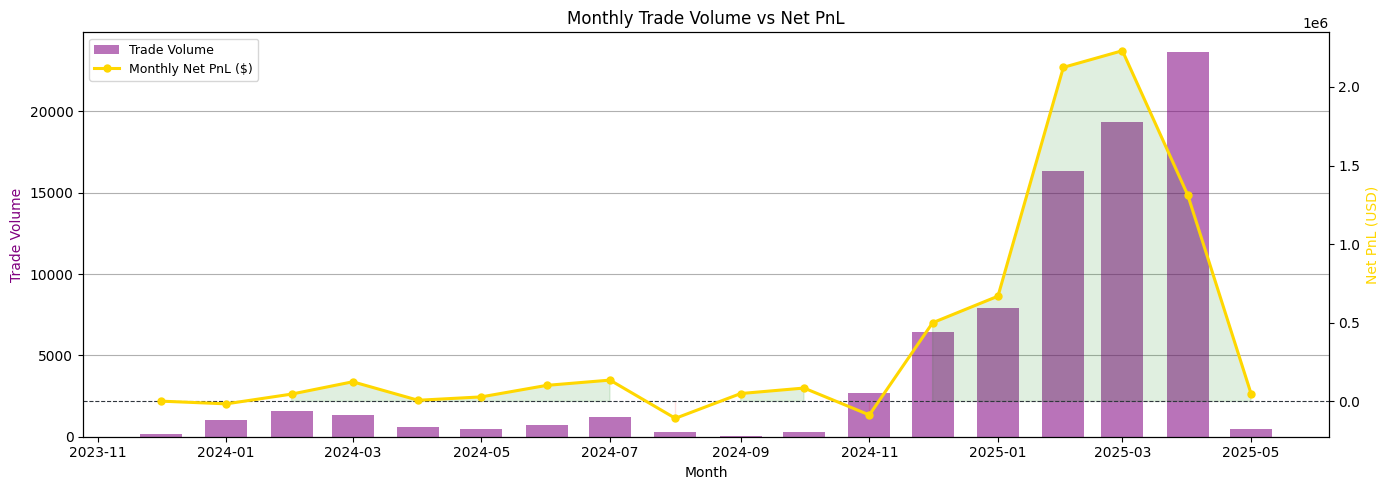

In [42]:
closed_df["month"] = closed_df["date"].dt.to_period("M").dt.to_timestamp()
monthly = closed_df.groupby("month").agg(
    trade_count=("net_pnl","count"),
    total_pnl=("net_pnl","sum")
).reset_index()
 
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
 
ax1.bar(monthly["month"], monthly["trade_count"],
        color='PURPLE', alpha=0.55, width=20, label="Trade Volume", zorder=2)
ax2.plot(monthly["month"], monthly["total_pnl"],
         color='GOLD', linewidth=2.2, marker="o", markersize=5,
         label="Monthly Net PnL ($)", zorder=3)
ax2.fill_between(monthly["month"], monthly["total_pnl"], 0,
                 where=monthly["total_pnl"]>=0, alpha=0.12, color='GREEN')
ax2.fill_between(monthly["month"], monthly["total_pnl"], 0,
                 where=monthly["total_pnl"]<0, alpha=0.12, color='RED')
ax2.axhline(0, color="#30363d", linewidth=0.8, linestyle="--")
 
ax1.set_xlabel("Month")
ax1.set_ylabel("Trade Volume", color='PURPLE')
ax2.set_ylabel("Net PnL (USD)", color='GOLD')
ax1.set_title("Monthly Trade Volume vs Net PnL")
plt.xticks(rotation=30, ha="right")
ax1.grid(True, axis="y", zorder=0)
 
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("10_monthly_volume_vs_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

### Monthly Trade Volume vs Net PnL Insights
### Monthly Trade Volume vs Net PnL shows trade volume explosion in March'25- April'25 with higher profitability(win rate). This could be due to increased market activity, favorable trading conditions, or specific events during that period. The correlation between trade volume and profitability suggests that higher trading activity may have contributed to better performance during these months.

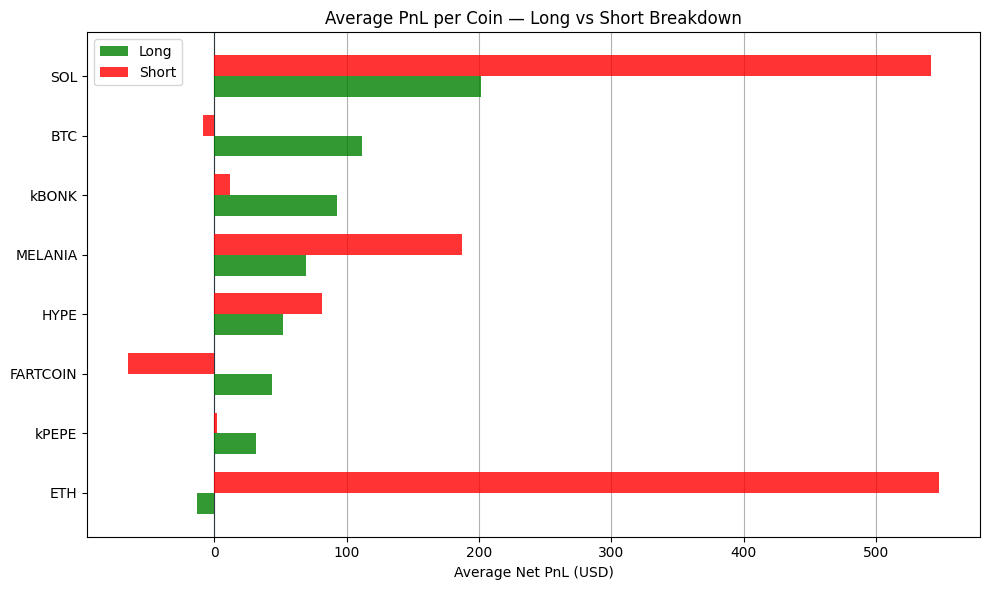

In [43]:
coin_dir = (
    closed_df[closed_df["Coin"].isin(TOP_COINS)]
    .groupby(["Coin","is_long"])["net_pnl"]
    .mean().unstack()
)
coin_dir.columns = ["Short", "Long"]
coin_dir = coin_dir.sort_values("Long", ascending=True)
 
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(coin_dir)); w = 0.35
ax.barh([i-w/2 for i in x], coin_dir["Long"].values,
        height=w, color='GREEN', alpha=0.8, label="Long", zorder=3)
ax.barh([i+w/2 for i in x], coin_dir["Short"].values,
        height=w, color='RED',   alpha=0.8, label="Short", zorder=3)
ax.set_yticks(list(x)); ax.set_yticklabels(coin_dir.index)
ax.axvline(0, color="#30363d", linewidth=0.8)
ax.set_xlabel("Average Net PnL (USD)")
ax.set_title("Average PnL per Coin — Long vs Short Breakdown")
ax.legend(); ax.grid(True, axis="x", zorder=0)
plt.tight_layout()
plt.savefig("11_coin_long_vs_short_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

### Average PnL per Coin vs Direction Insights
### Average PnL per Coin — Long vs Short Breakdown shows SOL and ETH have highest average PnL for short trades while BTC and FARTCOIN give losses on short trades. On the long side, SOL, BTC and kBONK have higher average PnL and ETH gives losses on long trades.

#### Trader Level Segments

In [44]:
traders_df = closed_df.groupby('Account').agg({
    'net_pnl': ['mean', 'std'],
    'is_win': 'mean',
    'Size USD': 'mean',
    'Crossed': 'mean'
}).reset_index()

traders_df.columns = [
    'Account',
    'avg_pnl',
    'pnl_std',
    'win_rate',
    'avg_size',
    'aggression'
]

In [45]:
traders_df.head()

,Account,avg_pnl,pnl_std,win_rate,avg_size,aggression
0,0x083384f897ee0f19899168e3b1bec365f52a9012,921.679535,6934.000605,0.792605,17310.457649,0.128250
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.064438,45.793266,0.867089,2015.746491,0.491561
2,0x271b280974205ca63b716753467d5a371de622ab,-48.200769,844.858426,0.668128,10621.476212,0.871008
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2.295651,133.033408,0.834655,587.803598,0.944885
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,81.196184,316.504091,0.814563,2508.635146,0.631068


In [46]:
trades_per_day = closed_df.groupby(['Account', 'date']).size().reset_index(name='num_trades')
avg_trades_per_day = trades_per_day.groupby('Account')['num_trades'].mean().reset_index()

traders_df = traders_df.merge(avg_trades_per_day, on='Account')

In [47]:
#segment 1- high risk
threshold = traders_df['avg_size'].median()

traders_df['risk_segment'] = traders_df['avg_size'].apply(
    lambda x: 'High Risk' if x > threshold else 'Low Risk'
)

In [48]:
#segment 2 - frequent
threshold = traders_df['num_trades'].median()

traders_df['frequency_segment'] = traders_df['num_trades'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

In [49]:
#segment 3- consistent
threshold = traders_df['pnl_std'].median()

traders_df['consistency_segment'] = traders_df['pnl_std'].apply(
    lambda x: 'Inconsistent' if x > threshold else 'Consistent'
)

In [50]:
#Comparison of Segments

#Risk Segment
risk_traders=traders_df.groupby('risk_segment')[['avg_pnl', 'win_rate']].mean()
print(risk_traders)

#Frequency Segment
freq_traders=traders_df.groupby('frequency_segment')[['avg_pnl', 'win_rate']].mean()
print(freq_traders)

#Consistency Segment
cons_traders=traders_df.groupby('consistency_segment')[['avg_pnl', 'win_rate']].mean()
print(cons_traders)

                 avg_pnl  win_rate
risk_segment                      
High Risk     158.806210  0.813180
Low Risk      118.962813  0.859866
                      avg_pnl  win_rate
frequency_segment                      
Frequent           168.201289  0.848056
Infrequent         109.567735  0.824991
                        avg_pnl  win_rate
consistency_segment                      
Consistent            49.119560  0.865711
Inconsistent         228.649464  0.807335


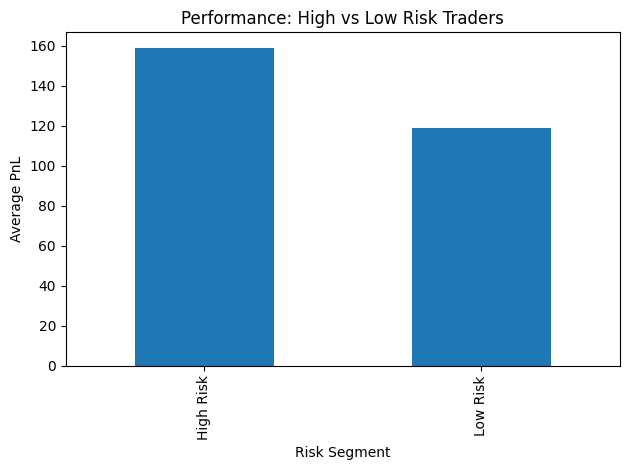

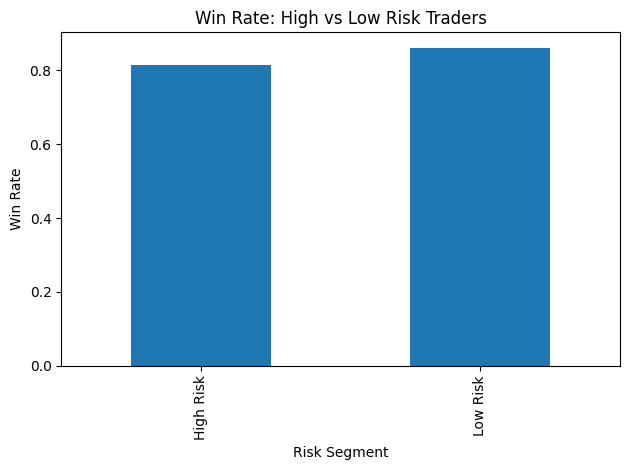

In [51]:
traders_df.groupby('risk_segment')['avg_pnl'].mean().plot(kind='bar')
plt.title('Performance: High vs Low Risk Traders')
plt.xlabel('Risk Segment')
plt.ylabel('Average PnL')
plt.tight_layout()
plt.savefig("12_performance_high_vs_low_risk.png", dpi=150, bbox_inches="tight")
plt.show()

traders_df.groupby('risk_segment')['win_rate'].mean().plot(kind='bar')

plt.title('Win Rate: High vs Low Risk Traders')
plt.xlabel('Risk Segment')
plt.ylabel('Win Rate')
plt.tight_layout()
plt.savefig("13_winrate_high_vs_low_risk.png", dpi=150, bbox_inches="tight")
plt.show()

### Risk(high vs low leverage) Segement Traders-High risk traders have more average pnl but lower win rate compared to low risk traders.

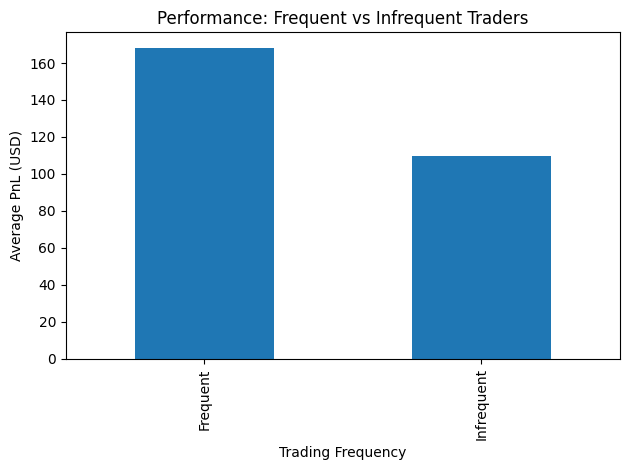

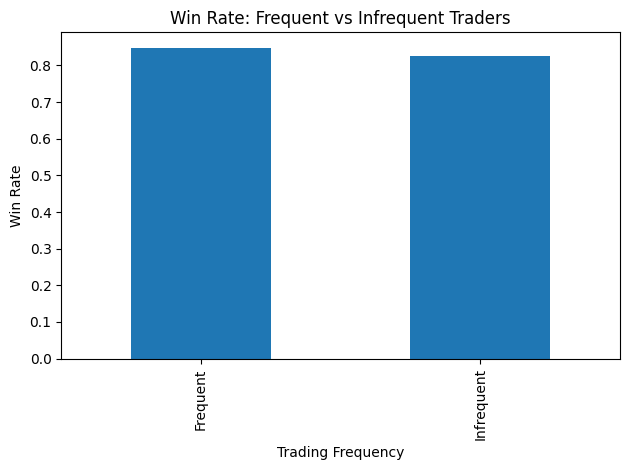

In [52]:
traders_df.groupby('frequency_segment')['avg_pnl'].mean().plot(kind='bar')

plt.title('Performance: Frequent vs Infrequent Traders')
plt.xlabel('Trading Frequency')
plt.ylabel('Average PnL (USD)')
plt.tight_layout()
plt.savefig("14_performance_frequent_vs_infrequent.png", dpi=150, bbox_inches="tight")
plt.show()

traders_df.groupby('frequency_segment')['win_rate'].mean().plot(kind='bar')

plt.title('Win Rate: Frequent vs Infrequent Traders')
plt.xlabel('Trading Frequency')
plt.ylabel('Win Rate')
plt.tight_layout()
plt.savefig("15_winrate_frequent_vs_infrequent.png", dpi=150, bbox_inches="tight")
plt.show()

### Frequent vs Infrequent Traders- Athough Frequent traders have higher average pnl,Infrequent Traders have almost same win rate as frequent traders. Hence, Frequent trading does not necessarily lead to higher win rate.

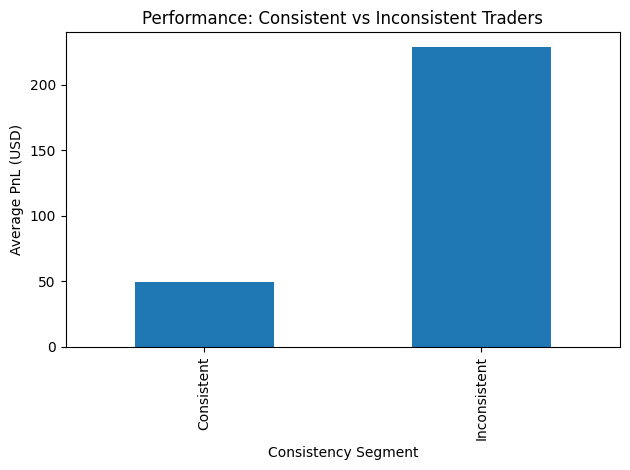

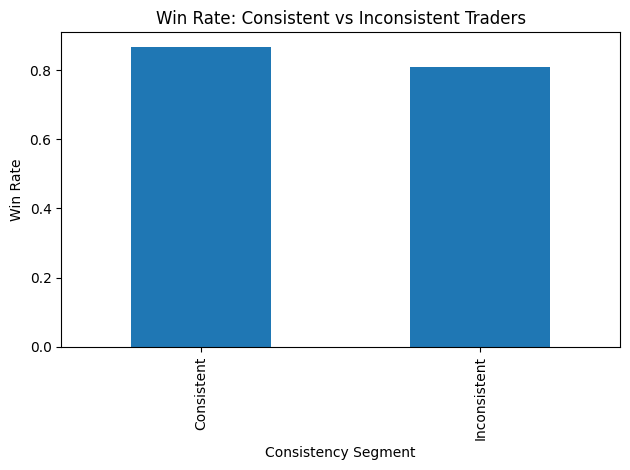

In [53]:
traders_df.groupby('consistency_segment')['avg_pnl'].mean().plot(kind='bar')

plt.title('Performance: Consistent vs Inconsistent Traders')
plt.xlabel('Consistency Segment')
plt.ylabel('Average PnL (USD)')
plt.tight_layout()
plt.savefig("16_performance_consistent_vs_inconsistent.png", dpi=150, bbox_inches="tight")
plt.show()

traders_df.groupby('consistency_segment')['win_rate'].mean().plot(kind='bar')

plt.title('Win Rate: Consistent vs Inconsistent Traders')
plt.xlabel('Consistency Segment')
plt.ylabel('Win Rate')
plt.tight_layout()
plt.savefig("17_winrate_consistent_vs_inconsistent.png", dpi=150, bbox_inches="tight")
plt.show()

### Consistent vs Inconsistent Traders- Although inconsistent traders have higher average pnl, but consistent traders have higher win rate. Hence, consistency beats inconsistency in win rates.

##### Trader and Sentiment Level Segments

In [54]:
trader_sentiment_df = closed_df.groupby(['Account', 'classification']).agg({
    'net_pnl': 'mean',
    'is_win': 'mean',
    'Size USD': 'mean',
    'Crossed': 'mean'
}).reset_index()

trader_sentiment_df.columns = [
    'Account',
    'classification',
    'avg_pnl',
    'win_rate',
    'avg_size',
    'aggression'
]

In [55]:
trades_per_day = closed_df.groupby(['Account', 'classification', 'date']).size().reset_index(name='num_trades')

freq_df = trades_per_day.groupby(['Account', 'classification'])['num_trades'].mean().reset_index()
trader_sentiment_df = trader_sentiment_df.merge(freq_df, on=['Account', 'classification'])

In [56]:
# Risk segment
threshold = trader_sentiment_df['avg_size'].median()
trader_sentiment_df['risk_segment'] = trader_sentiment_df['avg_size'].apply(
    lambda x: 'High Risk' if x > threshold else 'Low Risk'
)

# Frequency segment
threshold = trader_sentiment_df['num_trades'].median()
trader_sentiment_df['frequency_segment'] = trader_sentiment_df['num_trades'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

In [57]:
trader_sentiment_df.head()

,Account,classification,avg_pnl,win_rate,avg_size,aggression,num_trades,risk_segment,frequency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,3370.198549,1.000000,20332.521622,0.000000,18.50,High Risk,Infrequent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-166.358678,0.256098,15070.897764,0.142276,49.20,High Risk,Frequent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1057.791114,0.890476,16105.949476,0.067619,210.00,High Risk,Frequent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,1803.980639,0.601307,29572.417190,0.346405,51.00,High Risk,Frequent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,510.059002,1.000000,16607.474531,0.257143,61.25,High Risk,Frequent


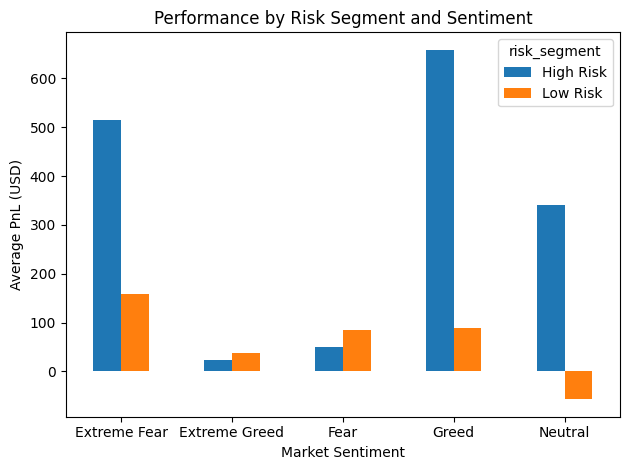

In [58]:
trader_sentiment_df.groupby(['classification', 'risk_segment'])['avg_pnl'].mean().unstack().plot(kind='bar')

plt.title('Performance by Risk Segment and Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average PnL (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("18_performance_risk_segment_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

### Strategy Idea 1 - Low risk traders are losing money on neutral days and hence they should trade more in greed, fear or extreme days to have greater average pnl as their performance is better in those days and high risk traders performed poorly on extreme greed days so they should avoid high size trades on those days.

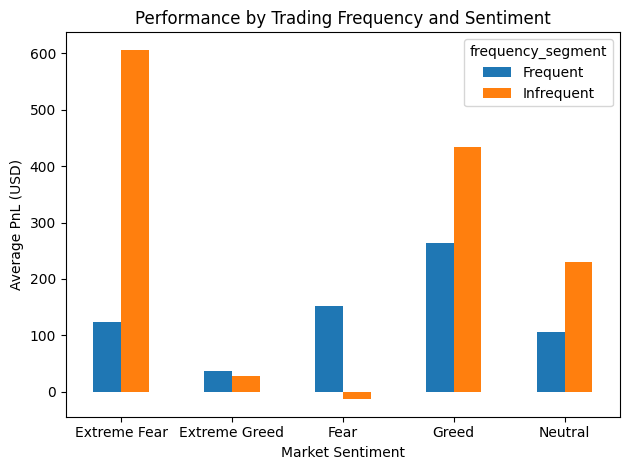

In [59]:
trader_sentiment_df.groupby(['classification', 'frequency_segment'])['avg_pnl'].mean().unstack().plot(kind='bar')

plt.title('Performance by Trading Frequency and Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average PnL (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("19_performance_frequency_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

### Strategy Idea 2 - Infrequent traders are losing money on fear days and outperforming on greed and extreme fear days hence they should trade more on greed, neutral and extreme fear days and avoid trading on fear days.

### Saving Closed Trades dataframe into a csv file for reference.

In [60]:
closed_df.to_csv('Closed_Trades.csv')